In [4]:
import pandas as pd
from PIL import Image
import numpy as np
import json
import torchvision
import torch
from os import path
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
import torchvision.transforms.functional as F
from tqdm import tqdm

device = "mps"

In [5]:
# Load movie metadata 
with open("../data/movies_2_option1.json", "r") as f:
    data = json.load(f)

# Get cleaned poster names that map to the images saved with matching names
cleaned_poster_names = [name.split("/")[4] + ".jpg" for name in data.keys()]

In [6]:
movie_names = [
    "recep-ivedik-2.jpg",
    "harry-potter-and-the-prisoner-of-azkaban.jpg",
    "inside-out-2015.jpg",
    "back-to-the-future.jpg",
    "the-notebook.jpg",
    "scream.jpg",
    "no-other-land.jpg",
]

for movie_name in movie_names:
    cleaned_poster_names.remove(movie_name)

In [7]:
# Load images and map PIL.Image object to the movie name
loaded_images = {}
not_found_poster_count = 0

for poster_name in tqdm(cleaned_poster_names):
    try:
        img_path = path.join("../data/posters/", poster_name)
        with Image.open(img_path) as img:
            loaded_images[poster_name] = img.copy()
    except:
        not_found_poster_count += 1

100%|██████████| 129055/129055 [00:47<00:00, 2708.84it/s] 


In [8]:
# Get all unique genres
genre_set = set()
for value in data.values():
    spec_genres = value.get("genre", None)
    if spec_genres:
        for genre in spec_genres:
            genre_set.add(genre)

# Map each genre to a row to use in multi-hot encodings
genre_mapping = {genre:idx for idx, genre in enumerate(genre_set)}

In [81]:
genre_mapping

{'Fantasy': 0,
 'Thriller': 1,
 'TV Movie': 2,
 'Animation': 3,
 'Documentary': 4,
 'Comedy': 5,
 'Other': 6,
 'Mystery': 7,
 'Family': 8,
 'Science Fiction': 9,
 'Action': 10,
 'Horror': 11,
 'Romance': 12,
 'Music': 13,
 'Drama': 14,
 'Crime': 15,
 'Adventure': 16}

In [9]:
# Create mappings of posters to multi-hot encoded labels (genres)
# Does not include movies with no genres
poster_labels = {}
for key, value in data.items():
    spec_genres = value.get("genre", None)
    multi_hot_blueprint = np.zeros(17, dtype=np.float32)
    if spec_genres:
        for genre in spec_genres:
            multi_hot_blueprint[genre_mapping[genre]] = 1
        poster_labels[key.split("/")[4] + ".jpg"] = torch.from_numpy(multi_hot_blueprint)

### Example

In [10]:
poster_labels.get("scott-pilgrim-vs-the-world.jpg")

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.])

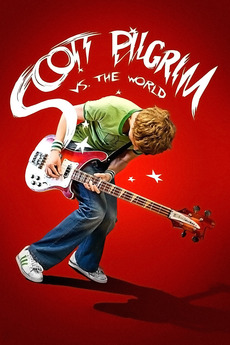

In [11]:
loaded_images.get("scott-pilgrim-vs-the-world.jpg")

### Fine-Tune ViT

In [12]:
class PosterDataset(Dataset):
    def __init__(self, poster_labels, loaded_images):
        self.x = loaded_images
        self.y = poster_labels

        self.common_movies = [movie for movie in poster_labels.keys() if movie in loaded_images.keys()]
        
        # TODO: Probably there is a lot more efficient way to do this but who cares
        self.x = {movie:loaded_images.get(movie) for movie in self.common_movies}
        self.y = {movie:poster_labels.get(movie) for movie in self.common_movies}

        # Init the transformer
        self.transformer = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.transforms() # Accepts batched PIL.Image (B, C, H, W) or single Tensor (C, H, W)

    def __getitem__(self, index):
        # Returns (PIL.Image, Multi-Hot Encoding)
        movie_name = self.common_movies[index]

        movie_poster = self.x[movie_name]
        movie_poster = movie_poster.convert("RGB") 
        movie_tensor = self.transformer(movie_poster)

        return movie_tensor, self.y.get(movie_name)

    def __len__(self):
        return len(self.common_movies)

In [13]:
torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [14]:
dataset = PosterDataset(poster_labels=poster_labels, loaded_images=loaded_images)

In [15]:
# Split dataset into train and validation
generator = torch.Generator().manual_seed(42) # Handles the remainders from the split, used for reproducability
small_dataset, _ = random_split(dataset, (0.2, 0.8), generator=generator)
train_dataset, val_dataset, test_dataset = random_split(dataset, (0.8, 0.1, 0.1), generator=generator)

In [16]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset)

In [17]:
# Load the VGG model with pretrained weights
model = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.DEFAULT)

In [18]:
model.parameters

<bound method Module.parameters of VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, eleme

In [19]:
for p in model.parameters():
    p.requires_grad = False

for p in model.heads.parameters():
    p.requires_grad = True

In [20]:
model.heads.head = nn.Linear(768, 17)

In [21]:
model.to(device)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [22]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(10):
    # Training
    model.train()
    train_loss = 0.0
    for i, (images, targets) in enumerate(train_dataloader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(images)    
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i, (images, targets) in enumerate(val_dataloader):
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)    
            loss = criterion(logits, targets)

            val_loss += loss.item()
            
            # if i % 100 == 0:
            #     print(f"Epoch {epoch} | Batch {i} | Loss {loss.item():.4f}")

    print(f"Epoch {epoch}: train_loss={train_loss / len(train_dataloader):.4f}, val_loss={val_loss / len(val_dataloader):.4f}")


Epoch 1: train_loss=0.7123, val_loss=0.7418
Epoch 2: train_loss=0.6679, val_loss=0.7012
Epoch 3: train_loss=0.6234, val_loss=0.6527
Epoch 4: train_loss=0.5811, val_loss=0.6195
Epoch 5: train_loss=0.5296, val_loss=0.5728
Epoch 6: train_loss=0.4724, val_loss=0.5239
Epoch 7: train_loss=0.4187, val_loss=0.4681
Epoch 8: train_loss=0.3615, val_loss=0.4126
Epoch 9: train_loss=0.3089, val_loss=0.3564
Epoch 10: train_loss=0.2527, val_loss=0.3198


In [63]:
model_preloaded = torchvision.models.vgg16(weights="IMAGENET1K_V1")
model_preloaded.classifier[6] = nn.Linear(4096, len(genre_set))

state_dict = torch.load("../models/one_epoch.pth", map_location=device)
model_preloaded.load_state_dict(state_dict)

model_preloaded.to(device)
model_preloaded.eval()
print("Completed")

Completed


In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss

In [65]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        images = images.to(device)
        labels = labels.to(device).int()

        logits = model_preloaded(images)
        preds = (torch.sigmoid(logits) > 0.3).int()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

100%|██████████| 9334/9334 [01:14<00:00, 124.82it/s]


In [66]:
all_preds = torch.cat(all_preds, dim=0)
all_labels = torch.cat(all_labels, dim=0)

In [ ]:
precision = precision_score(all_labels, all_preds, average="micro")
recall = recall_score(all_labels, all_preds, average="micro")
hamming_loss_metric = hamming_loss(all_labels, all_preds)
f1_score_metric = f1_score(all_labels, all_preds, average="micro")

print("Precision:", precision)
print("Recall:", recall)
print("Hamming Loss:", hamming_loss_metric)
print("F1 Score:", f1_score_metric)

Precision: 0.51010536398467434
Recall: 0.42332019908751556
Hamming Loss: 0.0090059365507506
F1 Score: 0.46645090619398525


### Example Movies - Demo

In [68]:
genres = ['Fantasy', 'Drama', 'Family', 'Romance', 'Animation', 'Adventure', 'TV Movie', 'Comedy', 'Crime', 'Thriller', 'Mystery', 'Science Fiction', 'Horror', 'Other', 'Action', 'Documentary', 'Music']

In [69]:
transformer = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.transforms()

In [70]:
movie_names = [
    "recep-ivedik-2.jpg",
    "harry-potter-and-the-prisoner-of-azkaban.jpg",
    "inside-out-2015.jpg",
    "back-to-the-future.jpg",
    "the-notebook.jpg",
    "scream.jpg",
    "no-other-land.jpg",
]

In [71]:
data_to_test = {}
for movie in movie_names:
    img_path = path.join("../data/posters/", movie)
    with Image.open(img_path) as img:
        data_to_test[movie] = img.copy()

In [ ]:
test_preds = {}
for test_image_name, test_image in data_to_test.items():
    images = transformer(test_image)
    with torch.no_grad():
        images = images.unsqueeze(0)  
        images = images.to(device)

        logits = model(images)
        preds = (torch.sigmoid(logits) > 0.3).int()
        test_preds[test_image_name] = preds

In [ ]:
test_movie_genres = {}

for test_name, preds in test_preds.items():
    pred = preds[0].cpu().tolist()

    predicted_genres = [genre for genre, flag in zip(genres, pred) if flag == 1]
    test_movie_genres[test_name] = predicted_genres
    print(test_name, predicted_genres)

recep-ivedik-2.jpg ['Comedy', 'Adventure', 'Drama']
harry-potter-and-the-prisoner-of-azkaban.jpg ['Adventure', 'Thriller', 'Science Fiction']
inside-out-2015.jpg ['Animation', 'Comedy', 'Family']
back-to-the-future.jpg ['Fantasy', 'Romance', 'Science Fiction', 'Other']
the-notebook.jpg ['Adventure', 'Romance', 'Music']
scream.jpg ['Adventure', 'Thriller']
no-other-land.jpg ['Documentary', 'Crime']


recep-ivedik-2.jpg


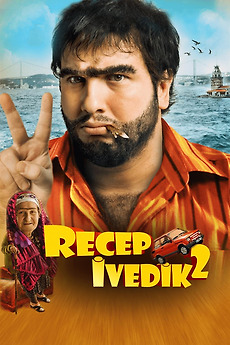

harry-potter-and-the-prisoner-of-azkaban.jpg


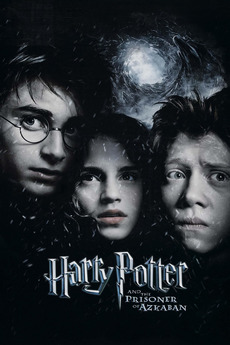

inside-out-2015.jpg


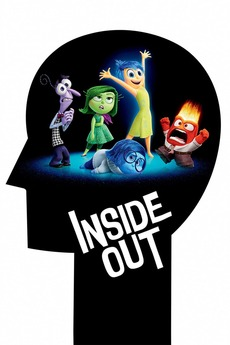

back-to-the-future.jpg


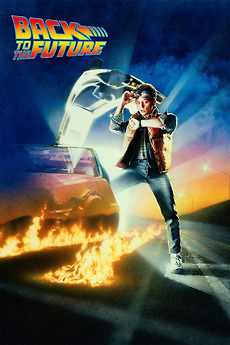

the-notebook.jpg


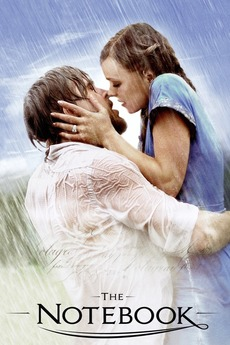

scream.jpg


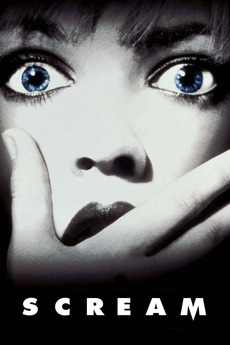

no-other-land.jpg


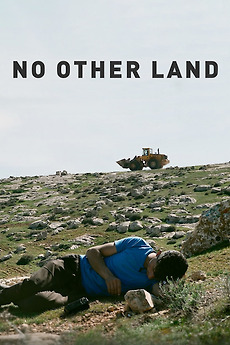

In [79]:
for name, poster in data_to_test.items():
    print(name)
    display(poster)

### Extra Analysis